# PEFT Methods Comparison on GLUE SST-2

Comparing Frozen Backbone, Full Fine-Tuning, LoRA, Adapters, Prefix-Tuning, and a Hybrid (LoRA + Prefix-Tuning) approach on DistilBERT.

## Setup

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00


In [ ]:
import math
import time
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
)
import evaluate

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU   : NVIDIA A100-SXM4-80GB
VRAM  : 85.1 GB


In [ ]:
MODEL_NAME    = "distilbert-base-uncased"
MAX_LENGTH    = 128
BATCH_SIZE    = 32
NUM_EPOCHS    = 3
LR_PEFT       = 2e-4
LR_FULL       = 2e-5
LORA_RANK     = 8
LORA_ALPHA    = 16
ADAPTER_DIM   = 64
PREFIX_TOKENS = 20
HIDDEN_SIZE   = 768
NUM_HEADS     = 12

## Data

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dataset   = load_dataset("glue", "sst2")

print(f"Train : {len(dataset['train']):,} examples")
print(f"Val   : {len(dataset['validation']):,} examples")
print(f"Test  : {len(dataset['test']):,} examples")
print(f"\nSample: \"{dataset['train'][0]['sentence']}\" → {dataset['train'][0]['label']}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train : 67,349 examples
Val   : 872 examples
Test  : 1,821 examples

Sample: "hide new secretions from the parental units " → 0


In [ ]:
def tokenize_fn(batch):
    return tokenizer(batch["sentence"], truncation=True, max_length=MAX_LENGTH)

tok_ds = dataset.map(tokenize_fn, batched=True)
tok_ds = tok_ds.remove_columns(["sentence", "idx"])
tok_ds = tok_ds.rename_column("label", "labels")
tok_ds.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

## Training Utilities

In [ ]:
metric = evaluate.load("glue", "sst2")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return metric.compute(predictions=preds, references=labels)

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def print_param_summary(model, name):
    total, trainable = count_params(model)
    pct = 100 * trainable / total
    print(f"  Total params     : {total:>12,}")
    print(f"  Trainable params : {trainable:>12,}  ({pct:.3f}%)")

In [ ]:
results = {}

def run_experiment(model, method_name, output_dir, lr=LR_PEFT):
    print(f"\n{'━'*65}")
    print(f"  METHOD: {method_name}")
    print(f"{'━'*65}")
    print_param_summary(model, method_name)

    training_args = TrainingArguments(
        output_dir          = output_dir,
        num_train_epochs    = NUM_EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = BATCH_SIZE,
        learning_rate       = lr,
        warmup_ratio        = 0.06,
        eval_strategy       = "epoch",
        save_strategy       = "epoch",
        load_best_model_at_end   = True,
        metric_for_best_model    = "accuracy",
        logging_steps       = 200,
        report_to           = "none",
        fp16                = torch.cuda.is_available(),
        seed                = SEED,
    )

    trainer = Trainer(
        model           = model,
        args            = training_args,
        train_dataset   = tok_ds["train"],
        eval_dataset    = tok_ds["validation"],
        processing_class= tokenizer,
        data_collator   = data_collator,
        compute_metrics = compute_metrics,
    )

    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0

    eval_out = trainer.evaluate()
    acc      = eval_out["eval_accuracy"]
    total, trainable = count_params(model)

    results[method_name] = {
        "Accuracy"         : acc,
        "Trainable Params" : trainable,
        "Total Params"     : total,
        "Trainable %"      : 100 * trainable / total,
        "Train Time (min)" : elapsed / 60,
    }

    print(f"\n  ✓ Accuracy : {acc:.4f}  |  Time: {elapsed/60:.1f} min")
    return trainer

## Method 1 — Frozen Backbone (Baseline)

In [ ]:
def make_frozen_model():
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    for name, param in model.named_parameters():
        if "classifier" not in name and "pre_classifier" not in name:
            param.requires_grad = False
    return model

run_experiment(make_frozen_model().to(device), "1. Frozen Backbone", "./out/frozen")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  METHOD: 1. Frozen Backbone
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total params     :   66,955,010
  Trainable params :      592,130  (0.884%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.356576,0.365404,0.834862
2,0.349933,0.360398,0.830275
3,0.342129,0.357299,0.836009


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



  ✓ Accuracy : 0.8360  |  Time: 1.6 min


## Method 2 — Full Fine-Tuning (Reference)

In [ ]:
model_full = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
run_experiment(model_full.to(device), "2. Full Fine-Tuning", "./out/full", lr=LR_FULL)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  METHOD: 2. Full Fine-Tuning
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total params     :   66,955,010
  Trainable params :   66,955,010  (100.000%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.175560,0.274698,0.902523
2,0.124092,0.340233,0.897936
3,0.069853,0.370926,0.896789


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



  ✓ Accuracy : 0.9025  |  Time: 2.9 min


## Method 3 — LoRA (Primary Reproduction)

Low-rank adaptation of attention query/value projections. Hu et al., ICLR 2022.

In [ ]:
def make_lora_model():
    base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    cfg  = LoraConfig(
        task_type      = TaskType.SEQ_CLS,
        r              = LORA_RANK,
        lora_alpha     = LORA_ALPHA,
        lora_dropout   = 0.1,
        target_modules = ["q_lin", "v_lin"],
        bias           = "none",
    )
    model = get_peft_model(base, cfg)
    model.print_trainable_parameters()
    return model

lora_model = make_lora_model()
run_experiment(lora_model.to(device), "3. LoRA (r=8)", "./out/lora")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  METHOD: 3. LoRA (r=8)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total params     :   67,694,596
  Trainable params :      739,586  (1.093%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.243297,0.282472,0.886468
2,0.217779,0.281825,0.893349
3,0.198075,0.290018,0.891055



  ✓ Accuracy : 0.8933  |  Time: 3.3 min


## Method 4 — Adapters

Bottleneck adapter modules inserted into each transformer block. Houlsby et al., ICML 2019.

In [ ]:
class AdapterModule(nn.Module):
    def __init__(self, hidden_size: int, bottleneck_size: int = 64):
        super().__init__()
        self.down = nn.Linear(hidden_size, bottleneck_size)
        self.up   = nn.Linear(bottleneck_size, hidden_size)
        self.act  = nn.GELU()
        nn.init.normal_(self.down.weight, std=1e-3)
        nn.init.zeros_(self.down.bias)
        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)

    def forward(self, x):
        return x + self.up(self.act(self.down(x)))


class AdaptedTransformerBlock(nn.Module):
    def __init__(self, original_block, hidden_size: int = 768, bottleneck: int = 64):
        super().__init__()
        self.block        = original_block
        self.adapter_attn = AdapterModule(hidden_size, bottleneck)
        self.adapter_ffn  = AdapterModule(hidden_size, bottleneck)

    def forward(self, hidden_states, attention_mask=None, **kwargs):
        attn_output, _ = self.block.attention(
            hidden_states,
            attention_mask=attention_mask,
            **kwargs,
        )
        attn_output = self.adapter_attn(attn_output)
        attn_output = self.block.sa_layer_norm(attn_output + hidden_states)

        ffn_output = self.block.ffn(attn_output)
        ffn_output = self.adapter_ffn(ffn_output)
        ffn_output = self.block.output_layer_norm(ffn_output + attn_output)

        return ffn_output

In [ ]:
def inject_adapters(model, bottleneck_size: int = 64):
    for p in model.parameters():
        p.requires_grad = False

    layers = model.distilbert.transformer.layer
    model.distilbert.transformer.layer = nn.ModuleList([
        AdaptedTransformerBlock(blk, hidden_size=HIDDEN_SIZE, bottleneck=bottleneck_size)
        for blk in layers
    ])

    for name, p in model.named_parameters():
        if any(k in name for k in ["adapter", "classifier", "pre_classifier"]):
            p.requires_grad = True

    return model


def make_adapter_model(bottleneck_size: int = 64):
    base  = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    return inject_adapters(base, bottleneck_size)

In [ ]:
adapter_model = make_adapter_model(ADAPTER_DIM)
run_experiment(adapter_model.to(device), f"4. Adapters (bottleneck={ADAPTER_DIM})", "./out/adapters")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  METHOD: 4. Adapters (bottleneck=64)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total params     :   68,144,642
  Trainable params :    1,781,762  (2.615%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.235240,0.260702,0.893349
2,0.198728,0.298967,0.892202
3,0.164090,0.297054,0.896789


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



  ✓ Accuracy : 0.8968  |  Time: 3.3 min


## Method 5 — Prefix-Tuning

Learnable key/value prefixes prepended at every attention layer. Li & Liang, ACL 2021.

Implemented as a custom wrapper because DistilBERT's `MultiHeadSelfAttention` does not accept `past_key_values`, which PEFT's `PrefixTuningConfig` relies on.

In [ ]:
class PrefixedTransformerBlock(nn.Module):
    def __init__(self, original_block, num_prefix_tokens: int = 20,
                 hidden_size: int = 768, n_heads: int = 12):
        super().__init__()
        self.block = original_block
        self.num_prefix_tokens = num_prefix_tokens
        self.n_heads = n_heads
        self.head_dim = hidden_size // n_heads
        self.prefix_k = nn.Parameter(
            torch.randn(1, n_heads, num_prefix_tokens, self.head_dim) * 0.02
        )
        self.prefix_v = nn.Parameter(
            torch.randn(1, n_heads, num_prefix_tokens, self.head_dim) * 0.02
        )

    def forward(self, hidden_states, attention_mask=None, **kwargs):
        attn = self.block.attention
        bs, seq_len, _ = hidden_states.size()

        def shape(x):
            return x.view(bs, -1, self.n_heads, self.head_dim).transpose(1, 2)

        def unshape(x):
            return x.transpose(1, 2).contiguous().view(bs, -1, self.n_heads * self.head_dim)

        q = shape(attn.q_lin(hidden_states))
        k = shape(attn.k_lin(hidden_states))
        v = shape(attn.v_lin(hidden_states))

        pk = self.prefix_k.expand(bs, -1, -1, -1)
        pv = self.prefix_v.expand(bs, -1, -1, -1)
        k = torch.cat([pk, k], dim=2)
        v = torch.cat([pv, v], dim=2)

        q = q / math.sqrt(self.head_dim)
        scores = torch.matmul(q, k.transpose(-2, -1))

        if attention_mask is not None:
            # The attention_mask passed to the block is the extended_attention_mask from DistilBertModel.
            # It could be (bs, 1, 1, original_seq_len) or (bs, 1, original_seq_len, original_seq_len).
            # For concatenation with prefix_mask (bs, 1, 1, num_prefix_tokens), the attention_mask
            # needs to have shape (bs, 1, 1, original_seq_len) to ensure dimensions match.
            attention_mask_for_cat = attention_mask
            if attention_mask.dim() == 4 and attention_mask.shape[2] != 1:
                # If attention_mask is (bs, 1, original_seq_len, original_seq_len), collapse the 3rd dim.
                attention_mask_for_cat = attention_mask[:, :, 0, :].unsqueeze(2)

            # Create a 4D prefix mask (bs, 1, 1, num_prefix_tokens)
            prefix_mask = torch.ones(
                bs, 1, 1, self.num_prefix_tokens,
                dtype=attention_mask_for_cat.dtype, device=attention_mask_for_cat.device,
            )
            # Concatenate along the last dimension (the sequence dimension)
            combined_mask = torch.cat([prefix_mask, attention_mask_for_cat], dim=-1)

            # Apply the combined mask to scores
            scores = scores.masked_fill((combined_mask == 0), torch.finfo(scores.dtype).min)

        weights = torch.softmax(scores, dim=-1)
        weights = attn.dropout(weights)
        attn_out = unshape(torch.matmul(weights, v))
        attn_out = attn.out_lin(attn_out)

        attn_out = self.block.sa_layer_norm(attn_out + hidden_states)
        ffn_out  = self.block.ffn(attn_out)
        ffn_out  = self.block.output_layer_norm(ffn_out + attn_out)
        return ffn_out

In [ ]:
def inject_prefix(model, num_prefix_tokens: int = 20):
    for p in model.parameters():
        p.requires_grad = False

    layers = model.distilbert.transformer.layer
    model.distilbert.transformer.layer = nn.ModuleList([
        PrefixedTransformerBlock(blk, num_prefix_tokens, HIDDEN_SIZE, NUM_HEADS)
        for blk in layers
    ])

    for name, p in model.named_parameters():
        if any(k in name for k in ["prefix", "classifier", "pre_classifier"]):
            p.requires_grad = True

    return model


def make_prefix_model(num_prefix_tokens: int = 20):
    base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    return inject_prefix(base, num_prefix_tokens)

In [ ]:
prefix_model = make_prefix_model(PREFIX_TOKENS)
run_experiment(prefix_model.to(device), f"5. Prefix-Tuning ({PREFIX_TOKENS} tokens)", "./out/prefix")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  METHOD: 5. Prefix-Tuning (20 tokens)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total params     :   67,139,330
  Trainable params :      776,450  (1.156%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.332464,0.348523,0.832569
2,0.321738,0.345863,0.838303
3,0.311438,0.343128,0.841743


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



  ✓ Accuracy : 0.8417  |  Time: 3.0 min


## Method 6 — Hybrid: LoRA + Prefix-Tuning

The proposed combination: LoRA adapts the attention weight matrices (low-rank delta on Q/V projections), while Prefix-Tuning prepends learned key/value vectors at every layer. Mechanisms are complementary — weight-space vs activation-space adaptation.

In [ ]:
def make_hybrid_model(num_prefix_tokens: int = 20):
    base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    lora_cfg = LoraConfig(
        task_type      = TaskType.SEQ_CLS,
        r              = LORA_RANK,
        lora_alpha     = LORA_ALPHA,
        lora_dropout   = 0.1,
        target_modules = ["q_lin", "v_lin"],
        bias           = "none",
    )
    model = get_peft_model(base, lora_cfg)

    inner = model.base_model.model.distilbert
    layers = inner.transformer.layer
    inner.transformer.layer = nn.ModuleList([
        PrefixedTransformerBlock(blk, num_prefix_tokens, HIDDEN_SIZE, NUM_HEADS)
        for blk in layers
    ])

    for name, p in model.named_parameters():
        if any(k in name for k in ["prefix", "classifier", "pre_classifier"]):
            p.requires_grad = True

    model.print_trainable_parameters()
    return model

hybrid_model = make_hybrid_model(PREFIX_TOKENS)
run_experiment(hybrid_model.to(device), "6. Hybrid: LoRA + Prefix-Tuning", "./out/hybrid")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,516,036 || all params: 67,878,916 || trainable%: 2.2334

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  METHOD: 6. Hybrid: LoRA + Prefix-Tuning
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total params     :   67,878,916
  Trainable params :    1,516,036  (2.233%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.246049,0.278138,0.888761
2,0.213138,0.300479,0.889908
3,0.195027,0.298451,0.894495



  ✓ Accuracy : 0.8945  |  Time: 4.0 min


## Results Summary

In [ ]:
print("\n\n" + "═"*75)
print("  FINAL RESULTS  —  GLUE SST-2 Accuracy Comparison")
print("═"*75)

df = pd.DataFrame(results).T.reset_index()
df.columns = ["Method", "Accuracy", "Trainable Params", "Total Params",
              "Trainable %", "Train Time (min)"]

df_display = df.copy()
df_display["Accuracy"]         = df["Accuracy"].map("{:.4f}".format)
df_display["Trainable Params"] = df["Trainable Params"].astype(int).map("{:,}".format)
df_display["Total Params"]     = df["Total Params"].astype(int).map("{:,}".format)
df_display["Trainable %"]      = df["Trainable %"].map("{:.3f}%".format)
df_display["Train Time (min)"] = df["Train Time (min)"].map("{:.1f}".format)

print(df_display.to_string(index=False))



═══════════════════════════════════════════════════════════════════════════
  FINAL RESULTS  —  GLUE SST-2 Accuracy Comparison
═══════════════════════════════════════════════════════════════════════════
                         Method Accuracy Trainable Params Total Params Trainable % Train Time (min)
             1. Frozen Backbone   0.8360          592,130   66,955,010      0.884%              1.6
            2. Full Fine-Tuning   0.9025       66,955,010   66,955,010    100.000%              2.9
                  3. LoRA (r=8)   0.8933          739,586   67,694,596      1.093%              3.3
    4. Adapters (bottleneck=64)   0.8968        1,781,762   68,144,642      2.615%              3.3
   5. Prefix-Tuning (20 tokens)   0.8417          776,450   67,139,330      1.156%              3.0
6. Hybrid: LoRA + Prefix-Tuning   0.8945        1,516,036   67,878,916      2.233%              4.0


In [ ]:
full_acc     = results.get("2. Full Fine-Tuning", {}).get("Accuracy", 0)
full_params  = results.get("2. Full Fine-Tuning", {}).get("Trainable Params", 1)

print("\n── Performance vs Full Fine-Tuning ──")
for name, r in results.items():
    gap = (r["Accuracy"] - full_acc) * 100
    param_ratio = r["Trainable Params"] / full_params * 100
    print(f"  {name:<40}  acc_gap={gap:+.2f}%   params={param_ratio:.1f}% of full")

df.to_csv("peft_sst2_results.csv", index=False)
print("\n✓ Results saved → peft_sst2_results.csv")


── Performance vs Full Fine-Tuning ──
  1. Frozen Backbone                        acc_gap=-6.65%   params=0.9% of full
  2. Full Fine-Tuning                       acc_gap=+0.00%   params=100.0% of full
  3. LoRA (r=8)                             acc_gap=-0.92%   params=1.1% of full
  4. Adapters (bottleneck=64)               acc_gap=-0.57%   params=2.7% of full
  5. Prefix-Tuning (20 tokens)              acc_gap=-6.08%   params=1.2% of full
  6. Hybrid: LoRA + Prefix-Tuning           acc_gap=-0.80%   params=2.3% of full

✓ Results saved → peft_sst2_results.csv


## Visualizations

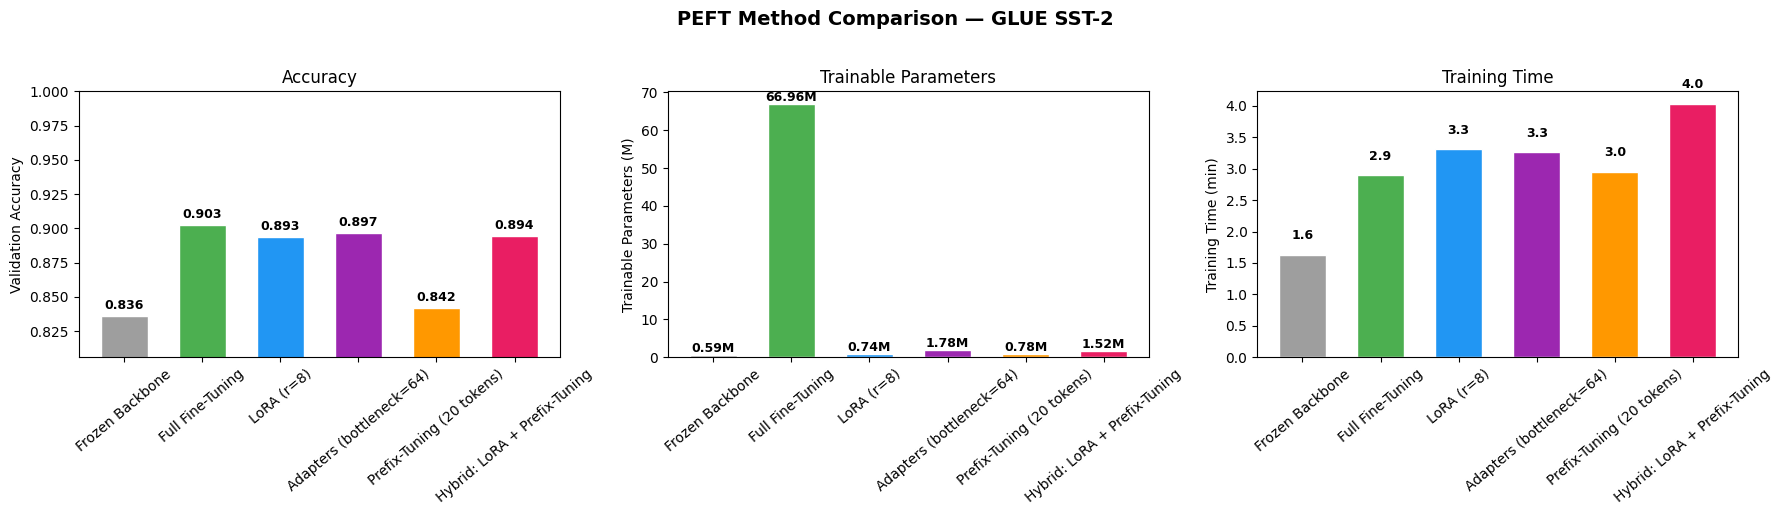

✓ Chart saved → peft_comparison.png


In [ ]:
import matplotlib.pyplot as plt

methods   = df["Method"].tolist()
accs      = df["Accuracy"].astype(float).tolist()
tr_params = (df["Trainable Params"].astype(int) / 1e6).tolist()
times     = df["Train Time (min)"].astype(float).tolist()

COLORS = ["#9E9E9E", "#4CAF50", "#2196F3", "#9C27B0", "#FF9800", "#E91E63"]
short_labels = [m.split(". ", 1)[-1] for m in methods]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PEFT Method Comparison — GLUE SST-2", fontsize=14, fontweight="bold", y=1.02)

ax = axes[0]
bars = ax.bar(short_labels, accs, color=COLORS, edgecolor="white", width=0.6)
ax.set_ylim(min(accs) - 0.03, 1.0)
ax.set_ylabel("Validation Accuracy")
ax.set_title("Accuracy")
ax.tick_params(axis="x", rotation=40)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax = axes[1]
bars = ax.bar(short_labels, tr_params, color=COLORS, edgecolor="white", width=0.6)
ax.set_ylabel("Trainable Parameters (M)")
ax.set_title("Trainable Parameters")
ax.tick_params(axis="x", rotation=40)
for bar, val in zip(bars, tr_params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}M", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax = axes[2]
bars = ax.bar(short_labels, times, color=COLORS, edgecolor="white", width=0.6)
ax.set_ylabel("Training Time (min)")
ax.set_title("Training Time")
ax.tick_params(axis="x", rotation=40)
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("peft_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved → peft_comparison.png")

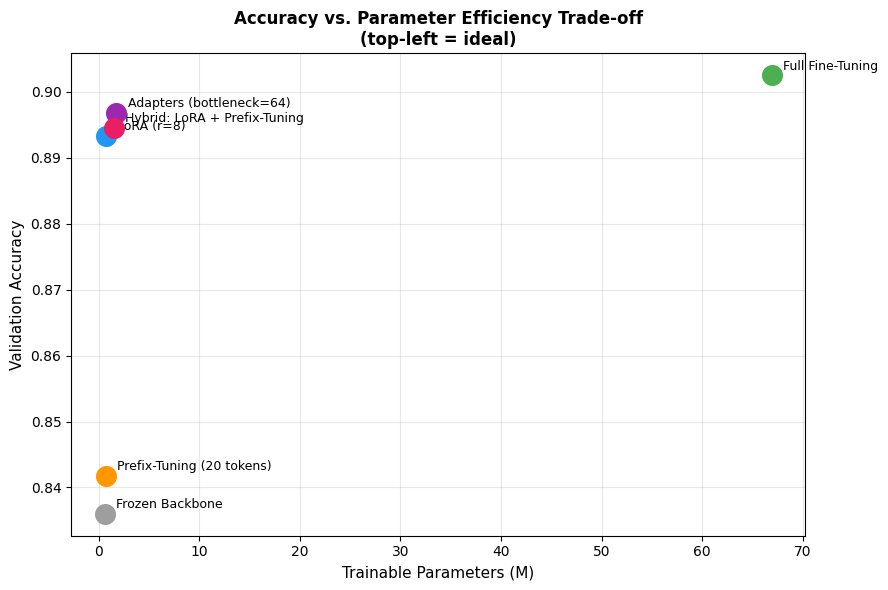

✓ Trade-off chart saved → peft_tradeoff.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, r) in enumerate(results.items()):
    label = name.split(". ", 1)[-1]
    x = r["Trainable Params"] / 1e6
    y = r["Accuracy"]
    ax.scatter(x, y, color=COLORS[i], s=200, zorder=5)
    ax.annotate(label, (x, y), textcoords="offset points",
                xytext=(8, 4), fontsize=9)

ax.set_xlabel("Trainable Parameters (M)", fontsize=11)
ax.set_ylabel("Validation Accuracy", fontsize=11)
ax.set_title("Accuracy vs. Parameter Efficiency Trade-off\n(top-left = ideal)",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("peft_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Trade-off chart saved → peft_tradeoff.png")

## LoRA Rank Ablation

In [ ]:
rank_results = {}

for r_val in [4, 8, 16]:
    base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    cfg  = LoraConfig(
        task_type      = TaskType.SEQ_CLS,
        r              = r_val,
        lora_alpha     = r_val * 2,
        lora_dropout   = 0.1,
        target_modules = ["q_lin", "v_lin"],
        bias           = "none",
    )
    m = get_peft_model(base, cfg).to(device)
    trainer = run_experiment(m, f"LoRA r={r_val}", f"./out/lora_r{r_val}")
    _, trainable = count_params(m)
    eval_out = trainer.evaluate()
    rank_results[f"r={r_val}"] = {
        "accuracy"        : eval_out["eval_accuracy"],
        "trainable_params": trainable,
    }

print("\n── LoRA Rank Ablation ──")
for k, v in rank_results.items():
    print(f"  {k}:  acc={v['accuracy']:.4f}  params={v['trainable_params']:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  METHOD: LoRA r=4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total params     :   67,620,868
  Trainable params :      665,858  (0.985%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.251975,0.284786,0.886468
2,0.227287,0.279652,0.889908
3,0.213713,0.286759,0.886468



  ✓ Accuracy : 0.8899  |  Time: 3.3 min


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  METHOD: LoRA r=16
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total params     :   67,842,052
  Trainable params :      887,042  (1.308%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.236248,0.290674,0.883028
2,0.203972,0.299043,0.892202
3,0.175687,0.324273,0.887615



  ✓ Accuracy : 0.8922  |  Time: 3.3 min

── LoRA Rank Ablation ──
  r=4:  acc=0.8899  params=665,858
  r=8:  acc=0.8899  params=739,586
  r=16:  acc=0.8922  params=887,042
